# **Hand Gesture Recognition**

It enables a computer to "see" and interpret human hand movements as digital commands. Instead of using traditional input devices like a mouse or keyboard, the user interacts with the machine using natural hand motions (e.g., a "thumbs up" to like a post, or a "palm open" to stop a video).

# **Why Use Hand Gesture Recognition (HGR)?**

Hand Gesture Recognition is becoming popular because it makes controlling technology feel natural and easy. Here is why it is useful:

**Touchless Control**: You do not need to touch any buttons or screens. This is very important in places like hospitals, where things need to stay clean, or for public screens like ATM machines.


**Accessibility:** It helps people who have trouble using a mouse or keyboard. They can use simple hand movements to control their computers, which makes technology more inclusive for everyone.


**Better Gaming and Virtual Reality (VR)**: In VR games, this technology makes you feel like you are really inside the game. You can grab or touch virtual objects with your hands, just like you do in real life.


**Natural Way to Control Devices:** It makes interacting with computers feel smooth and simple. Instead of needing extra tools, your own body becomes the remote control.

# **Model used:(CNN)**
 In this project, we used a  **CNN (Convolutional Neural Network)** model
 because it is highly effective for image classification tasks.
 CNN can automatically extract spatial features such as edges, textures, and shapes
 without manual feature engineering.
 Since our project involves recognizing hand gestures from images,
 CNN is the most suitable and widely used model for this purpose.

In [ ]:
import os
import cv2
from PIL import Image
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import Input, models, layers
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split

## **Display Image in Google Colab**

In [ ]:
from google.colab.patches import cv2_imshow

## **Unzip File**

In [ ]:
get_ipython().system('unzip -o "/content/HandGesture.zip"')

Streaming output truncated to the last 5000 lines.
  inflating: HandGesture/images/call_me/4057.jpg  
  inflating: HandGesture/images/call_me/4066.jpg  
  inflating: HandGesture/images/call_me/411.jpg  
  inflating: HandGesture/images/call_me/425.jpg  
  inflating: HandGesture/images/call_me/4327.jpg  
  inflating: HandGesture/images/call_me/4335.jpg  
  inflating: HandGesture/images/call_me/4341.jpg  
  inflating: HandGesture/images/call_me/4348.jpg  
  inflating: HandGesture/images/call_me/4355.jpg  
  inflating: HandGesture/images/call_me/4361.jpg  
  inflating: HandGesture/images/call_me/4370.jpg  
  inflating: HandGesture/images/call_me/4377.jpg  
  inflating: HandGesture/images/call_me/4385.jpg  
  inflating: HandGesture/images/call_me/4393.jpg  
  inflating: HandGesture/images/call_me/440.jpg  
  inflating: HandGesture/images/call_me/4402.jpg  
  inflating: HandGesture/images/call_me/4409.jpg  
  inflating: HandGesture/images/call_me/4417.jpg  
  inflating: HandGesture/images/ca

## **Mount Google Drive in Google Colab**
Connects Google Drive to Colab for file access

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
Dataset_Path="/content/HandGesture/images"

## **Total Classes**

In [ ]:
classes = [cls for cls in os.listdir(Dataset_Path)
           if os.path.isdir(os.path.join(Dataset_Path, cls))]

print("Total Classes:", len(classes))
print("Classes:", classes)


Total Classes: 10
Classes: ['rock', 'thumbs', 'up', 'fingers_crossed', 'scissor', 'rock_on', 'peace', 'call_me', 'okay', 'paper']


## **Total Images In Each Class**

In [ ]:
for cls in classes:
    cls_path = os.path.join(Dataset_Path, cls)
    img_count = len(os.listdir(cls_path))
    print(f"{cls} → {img_count} images")

rock → 508 images
thumbs → 537 images
up → 504 images
fingers_crossed → 504 images
scissor → 527 images
rock_on → 531 images
peace → 526 images
call_me → 527 images
okay → 540 images
paper → 539 images


## **Image Size**

In [ ]:
image_sizes = []

for cls in classes:
    cls_path = os.path.join(Dataset_Path, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path)
            image_sizes.append(img.size)
        except:
            pass

print("Unique image sizes:", set(image_sizes))

Unique image sizes: {(240, 195)}


## **Images Mode**

In [ ]:
print("Grayscale" if img.mode in ['L', '1'] else "RGB")

Grayscale


In [ ]:
print("Total images checked:", len(image_sizes))
print("Different sizes found:", len(set(image_sizes)))
print("Different color modes found:", len(set(image_modes)))


## **Display Sample Images from Each Class**

In [ ]:
for cls in classes:
    cls_path = os.path.join(Dataset_Path, cls)
    imgs = os.listdir(cls_path)
    sample_imgs = random.sample(imgs, min(3, len(imgs)))

    for img_name in sample_imgs:
        img = Image.open(os.path.join(cls_path, img_name))
        plt.imshow(img, cmap='gray' if img.mode=='L' else None)
        plt.title(f"{cls} | {img.size} | {img.mode}")
        plt.axis("off")
        plt.show()

## **Preprocessing Images for CNN Model**

In [ ]:
IMG_SIZE = 64

def preprocess_dataset(folder_path):
    data = []
    labels = []
    class_names = os.listdir(folder_path)

    for label, class_name in enumerate(class_names):
        class_path = os.path.join(folder_path, class_name)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)


            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            #  Resize
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            #  Normalize (0-255 → 0-1)
            img = img / 255.0

            img = np.expand_dims(img, axis=-1)

            data.append(img)
            labels.append(label)

    return np.array(data), np.array(labels), class_names



## **Original vs Processed Image Visualization**

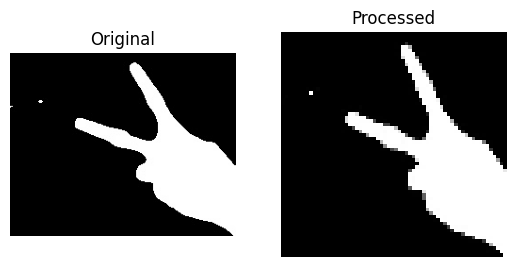

In [ ]:
cls = 'scissor'
img_path = os.path.join(Dataset_Path, cls, os.listdir(os.path.join(Dataset_Path, cls))[0])

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

orig = img
proc = cv2.resize(img, (64,64)) / 255.0

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(orig, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Processed")
plt.imshow(proc, cmap='gray')
plt.axis('off')

plt.show()

## **Train-Test Split of Dataset**

In [ ]:
# Load all data first
all_images, all_labels, class_names = preprocess_dataset(Dataset_Path)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    all_images, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 4194
Testing samples: 1049


## **CNN Model Architecture**

In [ ]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

## **Compile the CNN Model**

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

## **Train the CNN Model**
### **Epoch:**
One epoch means the model sees the entire training dataset once

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 21s 148ms/step - accuracy: 0.6614 - loss: 1.0086 - val_accuracy: 0.9142 - val_loss: 0.2992
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 19s 139ms/step - accuracy: 0.9444 - loss: 0.1920 - val_accuracy: 0.9504 - val_loss: 0.1469
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 17s 130ms/step - accuracy: 0.9776 - loss: 0.0680 - val_accuracy: 0.9495 - val_loss: 0.1648
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 18s 133ms/step - accuracy: 0.9881 - loss: 0.0353 - val_accuracy: 0.9561 - val_loss: 0.1460
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.9857 - loss: 0.0427 - val_accuracy: 0.9561 - val_loss: 0.1894
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step - accuracy: 0.9931 - loss: 0.0211 - val_accuracy: 0.9571 - val_loss: 0.1869
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - accuracy: 0.9938 - loss: 0.0204 - val_accuracy: 0.9666 - val_loss: 0.1321
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - accuracy: 0.9845 - loss: 0

### **Model Accuracy Graph**

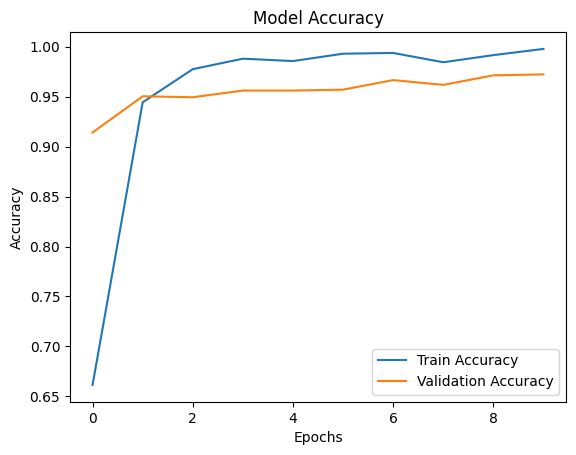

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## **Save Trained CNN Model**

In [ ]:
model.save("gesture_model.keras")

## **Random Image Prediction**

Predicting for image: /content/HandGesture/images/peace/1671.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
True Class: peace
Predicted Class: peace


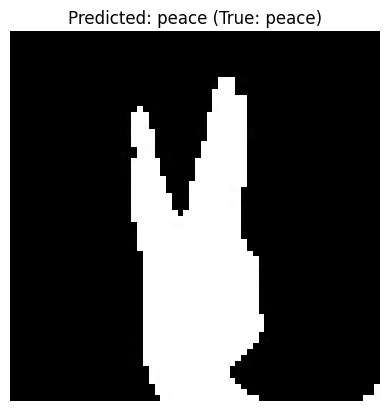

In [ ]:
import random

# Select a random class from the available classes
random_class_name = random.choice(class_names)

# Get a list of all images in that class directory
class_images_path = os.path.join(Dataset_Path, random_class_name)
all_images_in_class = os.listdir(class_images_path)

# Select a random image from that class
random_image_name = random.choice(all_images_in_class)
img_path = os.path.join(class_images_path, random_image_name)

print(f"Predicting for image: {img_path}")

# Load the image as grayscale and resize it to IMG_SIZE
img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE), color_mode='grayscale')

# Convert to array, normalize, and expand dimensions for model input
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0 # Add batch dimension and normalize

# Make prediction
prediction = model.predict(img_array)
predicted_class_index = np.argmax(prediction)
predicted_class_name = class_names[predicted_class_index]

print(f"True Class: {random_class_name}")
print(f"Predicted Class: {predicted_class_name}")

# Display the image
plt.imshow(img.convert('L'), cmap='gray') # convert('L') ensures it's 8-bit grayscale for display
plt.title(f"Predicted: {predicted_class_name} (True: {random_class_name})")
plt.axis('off')
plt.show()